# Extension Memo: Network Fragility and Redundancy Under Sea-Level Rise
### South Florida Tri-County Study Area (Broward, Miami-Dade, Palm Beach)

**Status:** Working draft — not for citation

---

This notebook builds a cohesive analysis dataset and preliminary findings for an extension of
Best et al. (2023). Rather than focusing only on *binary isolation* (is there any dry path?),
this project measures *network fragility* and *redundancy* under sea-level rise:

- **Isolated** — no dry route to services exists
- **Fragile** — connected, but only via a single dry path (edge-disjoint paths = 1)
- **Redundant** — connected with 2+ edge-disjoint dry paths

The central analytic argument: many blocks lose network redundancy — becoming fragile —
**before** they become fully isolated. Standard binary-isolation metrics miss this earlier
deterioration in network resilience.

## Motivation

Standard access-under-SLR analyses define a binary outcome: is the block reachable via some
dry path? This treats "barely connected through a single corridor" the same as "connected via
multiple independent routes." Network redundancy is a core resilience concept — a fragile
connection (one dry path) is qualitatively different from a redundant one, because a single
additional inundated edge can sever it completely.

### Conceptual Status Hierarchy

```
Redundant  →  Fragile  →  Isolated  →  Inundated
(2+ paths)   (1 path)    (0 paths)   (origin submerged)
```

As SLR increases, blocks may transition through this hierarchy. `Redundant → Fragile` is an
analytically distinct event — a loss of resilience — that binary isolation measures cannot detect.

### On Renaming `detour_ratio` to `path_inflation_ratio`

The raw data contain `detour_ratio = dry_shortest_path / baseline_shortest_path`. We rename
this to **`path_inflation_ratio`** in the analysis, with **"dry-path inflation ratio"** as the
preferred narrative label.

**Why not "detour ratio"?** The term implies a guaranteed commute-time effect. The network is
undirected, uses OSM segments intersected with NOAA inundation polygons, and does not model
traffic or turn restrictions. "Dry-path inflation ratio" is more precise: it measures how much
longer the *modeled* dry path is under the assumption that all inundated segments are
impassable. The raw `detour_ratio` column is preserved for traceability.

## 1. Setup and Project Paths

Import packages, configure paths, create output directories.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import json
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

try:
    import seaborn as sns
    HAS_SEABORN = True
    sns.set_theme(style="whitegrid", font_scale=0.95)
except ImportError:
    HAS_SEABORN = False
    print("NOTE: seaborn not installed — using matplotlib defaults.")

try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("WARNING: statsmodels not installed — regression section will be skipped.")

print("Imports complete.")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

Imports complete.


In [2]:
# ---------------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------------
# This notebook is expected to live in scripts/ within the project root.
# If your working directory differs, update PROJECT_ROOT below.
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Precomputed access flag run
RUN_DATE = "2026-04-03_run"
RUN_DIR  = PROJECT_ROOT / "data" / "processed" / "access" / "edited" / RUN_DATE
DIAG_DIR = RUN_DIR / "diagnostics"

# Analysis outputs
ANALYSIS_DIR = PROJECT_ROOT / "data" / "processed" / "analysis"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR   = PROJECT_ROOT / "outputs" / "tables"

for d in [ANALYSIS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Census API
CENSUS_API_KEY = "ff5d487d0a2a22c658bf319ba136c27db32aa0be"
CENSUS_YEAR    = "2022"

# Study area
STUDY_STATE    = "12"   # Florida
STUDY_COUNTIES = {"011": "Broward", "086": "Miami-Dade", "099": "Palm Beach"}
SLR_LEVELS     = list(range(1, 7))

# Dtypes for reading raw files — preserves leading zeros in GEOIDs
RESULT_DTYPE = {
    "block_geoid":                    "string",
    "block_group_geoid":              "string",
    "tract_geoid":                    "string",
    "block":                          "string",
    "county_fips":                    "string",
    "county_name":                    "string",
    "slr_layer_name":                 "string",
    "nearest_reachable_service_type": "string",
    "nearest_reachable_service_id":   "string",
    "baseline_status":                "string",
    "scenario_status":                "string",
}

# Visualization constants
STATUS_ORDER  = ["inundated", "isolated", "fragile", "redundant"]
STATUS_COLORS = {
    "inundated": "#1f78b4",
    "isolated":  "#d7301f",
    "fragile":   "#fdae61",
    "redundant": "#bdbdbd",
}
COUNTY_COLORS = {
    "Broward":    "#4daf4a",
    "Miami-Dade": "#984ea3",
    "Palm Beach": "#ff7f00",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Run directory: {RUN_DIR}")
assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"
print("Paths OK. Output directories ready.")

Project root : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access
Run directory: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\access\edited\2026-04-03_run
Paths OK. Output directories ready.


## 2. Inspect Scenario Files

Find all `block_access_flags_long*.csv` files, inventory their contents, and verify that the
baseline rows (`slr_ft == 0`) are consistent across files before extracting one canonical copy.

Each file contains:
- **Baseline rows** (`slr_ft == 0`) — identical across all 6 files (to be verified below)
- **Scenario rows** (`slr_ft == X`) — unique to each file

In [3]:
# Find scenario files
csv_files = sorted(
    p for p in RUN_DIR.glob("block_access_flags_long*.csv")
    if "qa_sample" not in p.stem
)
print(f"Found {len(csv_files)} scenario file(s):")
for f in csv_files:
    print(f"  {f.name}")

# Build file inventory
inventory_records = []
for path in csv_files:
    slim = pd.read_csv(path, usecols=["slr_ft"], dtype={"slr_ft": "Int64"})
    counts = slim["slr_ft"].value_counts().sort_index()
    inventory_records.append({
        "file_name":         path.name,
        "total_rows":        len(slim),
        "slr_ft_values":     ", ".join(str(int(x)) for x in counts.index.tolist()),
        "n_baseline_rows":   int(counts.get(0, 0)),
        "n_scenario_rows":   int(slim["slr_ft"].ne(0).sum()),
    })

inventory_df = pd.DataFrame(inventory_records)
display(inventory_df)

Found 6 scenario file(s):
  block_access_flags_longslr1.csv
  block_access_flags_longslr2.csv
  block_access_flags_longslr3.csv
  block_access_flags_longslr4.csv
  block_access_flags_longslr5.csv
  block_access_flags_longslr6.csv


,file_name,total_rows,slr_ft_values,n_baseline_rows,n_scenario_rows
0,block_access_flags_longslr1.csv,141390,"0, 1",70695,70695
1,block_access_flags_longslr2.csv,141390,"0, 2",70695,70695
2,block_access_flags_longslr3.csv,141390,"0, 3",70695,70695
3,block_access_flags_longslr4.csv,141390,"0, 4",70695,70695
4,block_access_flags_longslr5.csv,141390,"0, 5",70695,70695
5,block_access_flags_longslr6.csv,141390,"0, 6",70695,70695


In [4]:
# ---------------------------------------------------------------------------
# Verify baseline consistency: are the slr_ft==0 rows identical across files?
# ---------------------------------------------------------------------------
BASELINE_CHECK_COLS = [
    "block_geoid", "block_centroid_inundated", "block_centroid_isolated",
    "block_centroid_redundant", "block_centroid_fragile",
    "n_reachable_services", "max_edge_disjoint_paths_any_service",
    "baseline_status", "scenario_status",
]

baseline_frames = {}
for path in csv_files:
    df = pd.read_csv(path, usecols=["slr_ft"] + BASELINE_CHECK_COLS,
                     dtype={**RESULT_DTYPE, "slr_ft": "Int64"})
    df["slr_ft"] = df["slr_ft"].astype(int)
    bl = (df.loc[df["slr_ft"] == 0, BASELINE_CHECK_COLS]
           .sort_values("block_geoid")
           .reset_index(drop=True))
    baseline_frames[path.name] = bl
    print(f"  {path.name}: {len(bl):,} baseline rows")

ref_name = list(baseline_frames.keys())[0]
ref_bl   = baseline_frames[ref_name]

all_equal = True
for name, bl in baseline_frames.items():
    if name == ref_name:
        continue
    try:
        pd.testing.assert_frame_equal(ref_bl, bl, check_dtype=False)
    except AssertionError as e:
        print(f"WARNING — {name} baseline differs from {ref_name}: {e}")
        all_equal = False

if all_equal:
    print(f"\nBaseline consistency check PASSED across all {len(baseline_frames)} files.")
    print(f"Canonical baseline size: {len(ref_bl):,} blocks")
else:
    print("\nWARNING: Baseline inconsistency detected. Investigate before proceeding.")

  block_access_flags_longslr1.csv: 70,695 baseline rows
  block_access_flags_longslr2.csv: 70,695 baseline rows
  block_access_flags_longslr3.csv: 70,695 baseline rows
  block_access_flags_longslr4.csv: 70,695 baseline rows
  block_access_flags_longslr5.csv: 70,695 baseline rows
  block_access_flags_longslr6.csv: 70,695 baseline rows

Baseline consistency check PASSED across all 6 files.
Canonical baseline size: 70,695 blocks


## 3. Build Canonical Block-Level Long Dataset

**Design:**
1. Extract baseline (`slr_ft == 0`) from exactly one file (verified identical across all files above).
2. Load scenario-only rows (`slr_ft != 0`) from each file and stack.
3. Assert uniqueness on `(block_geoid, slr_ft)` before proceeding.
4. Standardize GEOID columns as zero-padded strings.
5. Create derived analysis variables.

### Key Variable Notes

**`path_inflation_ratio`** — renamed from raw `detour_ratio`.
- Definition: `dry_shortest_path_distance_m / baseline_shortest_path_distance_m`
- `= 1.0` if the dry route is unchanged; `> 1.0` if a longer route is needed due to inundated segments
- `NaN` if the block is isolated or inundated (no dry path exists — ratio is undefined)
- The raw `detour_ratio` column is preserved for traceability.

> **TODO**: The upstream code caps `max_edge_disjoint_paths_any_service` at 2
> (`MAX_EDGE_DISJOINT_PATHS_CAP = 2`). This means the model cannot distinguish 2-path from
> 3+ path redundancy. The fragile/redundant categories are therefore coarser than they appear.

In [5]:
# Extract one canonical baseline (slr_ft == 0) from the first file
ref_path = csv_files[0]
print(f"Loading baseline from: {ref_path.name}")

full_ref = pd.read_csv(ref_path, dtype=RESULT_DTYPE, low_memory=False)
full_ref["slr_ft"] = full_ref["slr_ft"].astype(int)

baseline_df = (full_ref.loc[full_ref["slr_ft"] == 0]
               .copy()
               .sort_values("block_geoid")
               .reset_index(drop=True))

assert baseline_df["block_geoid"].is_unique, "Duplicate block_geoid in baseline."
assert set(baseline_df["slr_ft"].unique()) == {0}, "Unexpected slr_ft in baseline."

print(f"Canonical baseline: {len(baseline_df):,} unique blocks")
del full_ref

Loading baseline from: block_access_flags_longslr1.csv
Canonical baseline: 70,695 unique blocks


In [6]:
# Load scenario rows (slr_ft != 0) from each file and stack
scenario_frames = []
for path in csv_files:
    df = pd.read_csv(path, dtype=RESULT_DTYPE, low_memory=False)
    df["slr_ft"] = df["slr_ft"].astype(int)
    scen = df.loc[df["slr_ft"] != 0].copy()
    scenario_frames.append(scen)
    print(f"  {path.name}: {len(scen):,} scenario rows")
    del df

scenarios_df = pd.concat(scenario_frames, ignore_index=True)
del scenario_frames

dupes = scenarios_df.duplicated(subset=["block_geoid", "slr_ft"])
if dupes.sum() > 0:
    print(f"WARNING: {dupes.sum()} duplicate (block_geoid, slr_ft) rows — keeping first.")
    scenarios_df = scenarios_df.loc[~dupes].copy()
else:
    print("No duplicate (block_geoid, slr_ft) rows. Good.")

scenarios_df = scenarios_df.sort_values(["slr_ft", "block_geoid"]).reset_index(drop=True)
print(f"\nScenario rows: {len(scenarios_df):,}")
print(f"SLR levels: {sorted(scenarios_df['slr_ft'].unique().tolist())}")
print(f"Unique blocks in scenarios: {scenarios_df['block_geoid'].nunique():,}")

  block_access_flags_longslr1.csv: 70,695 scenario rows
  block_access_flags_longslr2.csv: 70,695 scenario rows
  block_access_flags_longslr3.csv: 70,695 scenario rows
  block_access_flags_longslr4.csv: 70,695 scenario rows
  block_access_flags_longslr5.csv: 70,695 scenario rows
  block_access_flags_longslr6.csv: 70,695 scenario rows
No duplicate (block_geoid, slr_ft) rows. Good.

Scenario rows: 424,170
SLR levels: [1, 2, 3, 4, 5, 6]
Unique blocks in scenarios: 70,695


In [7]:
# Stack baseline + scenarios into one canonical long dataset
long_df = pd.concat([baseline_df, scenarios_df], ignore_index=True)
long_df = long_df.sort_values(["slr_ft", "block_geoid"]).reset_index(drop=True)

# Standardize GEOIDs
for col, width in [("block_geoid", 15), ("block_group_geoid", 12),
                   ("tract_geoid", 11), ("county_fips", 3)]:
    if col in long_df.columns:
        long_df[col] = long_df[col].astype(str).str.zfill(width)

# Row count checks
n_blocks   = baseline_df["block_geoid"].nunique()
n_expected = n_blocks * (1 + len(SLR_LEVELS))
n_actual   = len(long_df)
n_keys     = long_df.drop_duplicates(subset=["block_geoid", "slr_ft"]).shape[0]

print(f"Long dataset: {n_actual:,} rows")
print(f"  Unique (block_geoid, slr_ft) pairs: {n_keys:,}")
print(f"  Expected: {n_expected:,} ({n_blocks:,} blocks x {1 + len(SLR_LEVELS)} SLR levels)")

if n_actual != n_keys:
    print(f"WARNING: {n_actual - n_keys} duplicate rows detected.")
if n_actual != n_expected:
    print(f"WARNING: Row count {n_actual} differs from expected {n_expected}.")
else:
    print("Row count checks passed.")

display(long_df[["block_geoid", "block_group_geoid", "county_name",
                  "slr_ft", "scenario_status", "baseline_status"]].head(6))

Long dataset: 494,865 rows
  Unique (block_geoid, slr_ft) pairs: 494,865
  Expected: 494,865 (70,695 blocks x 7 SLR levels)
Row count checks passed.


,block_geoid,block_group_geoid,county_name,slr_ft,scenario_status,baseline_status
0,120110101021000,120110101021,Broward,0,redundant,redundant
1,120110101021001,120110101021,Broward,0,redundant,redundant
2,120110101021002,120110101021,Broward,0,inundated,inundated
3,120110101021003,120110101021,Broward,0,fragile,fragile
4,120110101021004,120110101021,Broward,0,redundant,redundant
5,120110101021005,120110101021,Broward,0,fragile,fragile


In [8]:
# ---------------------------------------------------------------------------
# Derived analysis variables
# ---------------------------------------------------------------------------

positive_slr = long_df["slr_ft"].gt(0)
baseline_redundant = long_df["baseline_block_centroid_redundant"].eq(1)
baseline_fragile = long_df["baseline_block_centroid_fragile"].eq(1)
baseline_isolated = long_df["baseline_block_centroid_isolated"].eq(1)

# 1. Ordered 4-category status
long_df["status_4cat"] = pd.Categorical(
    long_df["scenario_status"],
    categories=["inundated", "isolated", "fragile", "redundant"],
    ordered=True,
)

# 2. Fragile-or-worse: fragile | isolated | inundated
long_df["fragile_or_worse"] = (
    long_df["scenario_status"].isin(["fragile", "isolated", "inundated"])
).astype("Int8")

# 3. Transition indicators from the baseline redundant state.
# These are defined only for positive SLR scenarios.
long_df["baseline_redundant_to_fragile"] = (
    baseline_redundant & positive_slr & long_df["block_centroid_fragile"].eq(1)
).astype("Int8")
long_df["baseline_redundant_to_isolated"] = (
    baseline_redundant & positive_slr & long_df["block_centroid_isolated"].eq(1)
).astype("Int8")
long_df["baseline_redundant_to_inundated"] = (
    baseline_redundant & positive_slr & long_df["block_centroid_inundated"].eq(1)
).astype("Int8")
long_df["baseline_redundant_to_isolated_or_inundated"] = (
    baseline_redundant
    & positive_slr
    & (
        long_df["block_centroid_isolated"].eq(1)
        | long_df["block_centroid_inundated"].eq(1)
    )
).astype("Int8")
long_df["baseline_redundant_to_fragile_or_worse"] = (
    baseline_redundant
    & positive_slr
    & long_df["scenario_status"].isin(["fragile", "isolated", "inundated"])
).astype("Int8")

# Retain the existing alias used elsewhere in the notebook.
long_df["any_loss_of_redundancy"] = long_df["baseline_redundant_to_fragile_or_worse"].astype("Int8")

# 4. Additional transition indicators used elsewhere in the notebook.
long_df["baseline_fragile_persisted"] = (
    baseline_fragile & positive_slr & long_df["block_centroid_fragile"].eq(1)
).astype("Int8")
long_df["baseline_fragile_to_isolated"] = (
    baseline_fragile & positive_slr & long_df["block_centroid_isolated"].eq(1)
).astype("Int8")
long_df["baseline_fragile_to_inundated"] = (
    baseline_fragile & positive_slr & long_df["block_centroid_inundated"].eq(1)
).astype("Int8")
long_df["baseline_isolated_to_inundated"] = (
    baseline_isolated & positive_slr & long_df["block_centroid_inundated"].eq(1)
).astype("Int8")

# 5. Convenience aliases retained for existing non-map figures.
long_df["became_fragile"] = long_df["new_fragile_due_to_slr"].astype("Int8")
long_df["became_isolated"] = long_df["new_isolated_due_to_slr"].astype("Int8")
long_df["became_inundated"] = long_df["new_inundated_due_to_slr"].astype("Int8")

# 6. Path inflation ratio renamed from detour_ratio.
# Set to NaN for isolated/inundated blocks where no dry path exists.
long_df["path_inflation_ratio"] = pd.to_numeric(long_df["detour_ratio"], errors="coerce")

iso_or_inh = long_df["block_centroid_isolated"].eq(1) | long_df["block_centroid_inundated"].eq(1)
long_df.loc[iso_or_inh, "path_inflation_ratio"] = np.nan
long_df["path_inflation_ratio"] = long_df["path_inflation_ratio"].replace([np.inf, -np.inf], np.nan)

# Sanity: connected blocks should have ratio >= 1.0.
conn_mask = long_df["path_inflation_ratio"].notna()
below_one = (long_df.loc[conn_mask, "path_inflation_ratio"] < 0.99).sum()
if below_one > 0:
    print(f"WARNING: {below_one} connected blocks have path_inflation_ratio < 1.0 - investigate.")
else:
    print(
        f"path_inflation_ratio OK: {conn_mask.sum():,} connected, "
        f"{long_df['path_inflation_ratio'].isna().sum():,} NaN (isolated/inundated)."
    )

print("Derived variables created.")
display(
    long_df[
        [
            "block_geoid",
            "slr_ft",
            "scenario_status",
            "baseline_redundant_to_fragile",
            "baseline_redundant_to_isolated_or_inundated",
            "baseline_redundant_to_fragile_or_worse",
            "path_inflation_ratio",
        ]
    ].head(8)
)


path_inflation_ratio OK: 433,518 connected, 61,347 NaN (isolated/inundated).
Derived variables created.


,block_geoid,slr_ft,scenario_status,baseline_redundant_to_fragile,baseline_redundant_to_isolated_or_inundated,baseline_redundant_to_fragile_or_worse,path_inflation_ratio
0,120110101021000,0,redundant,0,0,0,1.0000
1,120110101021001,0,redundant,0,0,0,1.0000
2,120110101021002,0,inundated,0,0,0,NaN
3,120110101021003,0,fragile,0,0,0,1.0000
4,120110101021004,0,redundant,0,0,0,1.0000
5,120110101021005,0,fragile,0,0,0,1.0000
6,120110101021006,0,redundant,0,0,0,1.0000
7,120110101021007,0,redundant,0,0,0,1.0000


## 4. Validation and Diagnostics

Compare our canonical dataset against the precomputed diagnostic files in `diagnostics/`.
Any discrepancies are flagged explicitly — nothing is silently ignored.

In [9]:
# Reproduce baseline_vs_scenario_crosstab and compare to precomputed file
positive = long_df.loc[long_df["slr_ft"] != 0].copy()

crosstab_own = (
    positive
    .groupby(["slr_ft", "baseline_status", "scenario_status"], as_index=False)
    .agg(n_blocks_own=("block_geoid", "size"))
    .sort_values(["slr_ft", "baseline_status", "scenario_status"])
    .reset_index(drop=True)
)

crosstab_ref = (
    pd.read_csv(DIAG_DIR / "baseline_vs_scenario_crosstab.csv")
    .sort_values(["slr_ft", "baseline_status", "scenario_status"])
    .reset_index(drop=True)
)

comp = crosstab_ref.merge(
    crosstab_own,
    on=["slr_ft", "baseline_status", "scenario_status"],
    how="outer",
    validate="one_to_one",
).fillna(0)
comp["diff"] = comp["n_blocks"] - comp["n_blocks_own"]

if comp["diff"].abs().max() == 0:
    print("VALIDATION PASSED: crosstab matches precomputed diagnostic exactly.")
else:
    print(f"DISCREPANCY: max |diff| = {comp['diff'].abs().max()}")
    display(comp.loc[comp["diff"].ne(0)])

print("\nBaseline→Scenario crosstab from canonical dataset:")
display(crosstab_own)

VALIDATION PASSED: crosstab matches precomputed diagnostic exactly.

Baseline→Scenario crosstab from canonical dataset:


,slr_ft,baseline_status,scenario_status,n_blocks_own
0,1,fragile,fragile,17399
1,1,fragile,inundated,57
2,1,fragile,isolated,2
3,1,inundated,inundated,1095
4,1,isolated,inundated,19
5,1,isolated,isolated,2451
6,1,redundant,fragile,15
7,1,redundant,inundated,31
8,1,redundant,isolated,8
9,1,redundant,redundant,49618


In [10]:
# Reproduce transition_summary_by_slr and cross-check
transition_own = (
    positive
    .groupby("slr_ft", as_index=False)
    .agg(
        n_blocks = ("block_geoid", "size"),
        n_baseline_redundant_blocks = ("baseline_block_centroid_redundant", "sum"),
        n_new_fragile = ("new_fragile_due_to_slr", "sum"),
        n_new_isolated = ("new_isolated_due_to_slr", "sum"),
        n_new_inundated = ("new_inundated_due_to_slr", "sum"),
        n_baseline_redundant_to_fragile = ("baseline_redundant_to_fragile", "sum"),
        n_baseline_redundant_to_isolated = ("baseline_redundant_to_isolated", "sum"),
        n_baseline_redundant_to_inundated = ("baseline_redundant_to_inundated", "sum"),
        n_baseline_redundant_to_isolated_or_inundated = (
            "baseline_redundant_to_isolated_or_inundated",
            "sum",
        ),
        n_baseline_redundant_to_fragile_or_worse = (
            "baseline_redundant_to_fragile_or_worse",
            "sum",
        ),
        n_any_loss_of_redundancy = ("any_loss_of_redundancy", "sum"),
    )
    .sort_values("slr_ft")
    .reset_index(drop=True)
)

transition_ref = pd.read_csv(DIAG_DIR / "transition_summary_by_slr.csv")

# Cross-check key columns already present in the reference diagnostic.
check_pairs = [
    ("new_fragile_due_to_slr", "n_new_fragile"),
    ("new_isolated_due_to_slr", "n_new_isolated"),
    ("new_inundated_due_to_slr", "n_new_inundated"),
]
all_ok = True
for ref_col, own_col in check_pairs:
    if ref_col not in transition_ref.columns:
        continue
    for slr in SLR_LEVELS:
        ref_val = int(transition_ref.loc[transition_ref["slr_ft"] == slr, ref_col].iloc[0])
        own_val = int(transition_own.loc[transition_own["slr_ft"] == slr, own_col].iloc[0])
        if ref_val != own_val:
            print(f"MISMATCH slr={slr} {ref_col}: ref={ref_val}, own={own_val}")
            all_ok = False
if all_ok:
    print("VALIDATION PASSED: transition counts match precomputed file.")

print("\nTransition summary from canonical dataset:")
display(transition_own)


VALIDATION PASSED: transition counts match precomputed file.

Transition summary from canonical dataset:


,slr_ft,n_blocks,n_baseline_redundant_blocks,n_new_fragile,n_new_isolated,n_new_inundated,n_baseline_redundant_to_fragile,n_baseline_redundant_to_isolated,n_baseline_redundant_to_inundated,n_baseline_redundant_to_isolated_or_inundated,n_baseline_redundant_to_fragile_or_worse,n_any_loss_of_redundancy
0,1,70695,49672,15,10,107,15,8,31,39,54,54
1,2,70695,49672,154,349,308,154,153,132,285,439,439
2,3,70695,49672,532,1089,1144,532,578,613,1191,1723,1723
3,4,70695,49672,730,1938,2839,730,1111,1666,2777,3507,3507
4,5,70695,49672,1302,3482,6490,1302,2297,4156,6453,7755,7755
5,6,70695,49672,1403,6539,13816,1403,4834,9414,14248,15651,15651


In [11]:
# County-level status summary
county_status = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["slr_ft", "county_name", "scenario_status"], as_index=False)
    .agg(n_blocks=("block_geoid", "size"))
)
county_total = county_status.groupby(["slr_ft", "county_name"])["n_blocks"].transform("sum")
county_status["share"] = county_status["n_blocks"] / county_total

print("County-level status shares at SLR = 3 ft:")
piv = county_status.loc[county_status["slr_ft"] == 3].pivot_table(
    index="county_name", columns="scenario_status", values="share", fill_value=0
)
display(piv.round(4))

print("\nCounty-level status shares at SLR = 6 ft:")
piv6 = county_status.loc[county_status["slr_ft"] == 6].pivot_table(
    index="county_name", columns="scenario_status", values="share", fill_value=0
)
display(piv6.round(4))

County-level status shares at SLR = 3 ft:


scenario_status,fragile,inundated,isolated,redundant
county_name,,,,
Broward,0.2248,0.0252,0.0587,0.6913
Miami-Dade,0.1951,0.0394,0.0366,0.7290
Palm Beach,0.3426,0.0256,0.0570,0.5748



County-level status shares at SLR = 6 ft:


scenario_status,fragile,inundated,isolated,redundant
county_name,,,,
Broward,0.1517,0.2641,0.1352,0.4491
Miami-Dade,0.1450,0.2610,0.1291,0.4649
Palm Beach,0.3169,0.0621,0.0741,0.5469


## 5. Aggregate to Block Group for Analysis

Build block-group x SLR-scenario datasets for transition mapping and regression.

Transition-map denominators use the number of baseline-redundant blocks in each geography.
If a block group or tract has zero baseline-redundant blocks, the transition shares are set
to `NaN` so those geographies plot as missing rather than as zero.

> **Note on path_inflation_ratio:** mean and median are computed only over connected
> (non-isolated, non-inundated) blocks, since the ratio is undefined when no dry path exists.
> Interpret the conditional mean/median with care - it describes blocks that *can* reach
> services, not unconditional average network stress.


In [12]:
# ---------------------------------------------------------------------------
# Block-group x scenario aggregation
# ---------------------------------------------------------------------------
GROUP_KEYS = ["block_group_geoid", "county_fips", "county_name", "tract_geoid", "slr_ft"]

count_sum_cols = [
    "baseline_block_centroid_redundant",
    "block_centroid_inundated",
    "block_centroid_isolated",
    "block_centroid_fragile",
    "block_centroid_redundant",
    "fragile_or_worse",
    "any_loss_of_redundancy",
    "new_fragile_due_to_slr",
    "new_isolated_due_to_slr",
    "new_inundated_due_to_slr",
    "baseline_redundant_to_fragile",
    "baseline_redundant_to_isolated",
    "baseline_redundant_to_inundated",
    "baseline_redundant_to_isolated_or_inundated",
    "baseline_redundant_to_fragile_or_worse",
    "baseline_fragile_to_isolated",
    "baseline_fragile_to_inundated",
    "baseline_isolated_to_inundated",
]

# Step 1: Counts and sums.
count_sum_agg = {col: "sum" for col in count_sum_cols if col in long_df.columns}
count_sum_agg["block_geoid"] = "count"

bg_counts = (
    long_df.groupby(GROUP_KEYS)
    .agg(count_sum_agg)
    .reset_index()
    .rename(
        columns={
            "block_geoid": "total_blocks",
            "baseline_block_centroid_redundant": "baseline_redundant_blocks",
        }
    )
)

for col in [
    "total_blocks",
    "baseline_redundant_blocks",
    *[c for c in count_sum_cols if c in bg_counts.columns],
]:
    if col in bg_counts.columns:
        bg_counts[col] = bg_counts[col].astype(int)

# Step 2: Mean/median of max_edge_disjoint_paths.
bg_paths = (
    long_df.groupby(GROUP_KEYS)["max_edge_disjoint_paths_any_service"]
    .agg(["mean", "median"])
    .rename(
        columns={
            "mean": "mean_max_edge_disjoint_paths",
            "median": "median_max_edge_disjoint_paths",
        }
    )
    .reset_index()
)

# Step 3: Mean/median path_inflation_ratio (NaN-safe - skips isolated/inundated).
bg_pir = (
    long_df.groupby(["block_group_geoid", "slr_ft"])["path_inflation_ratio"]
    .agg(["mean", "median"])
    .rename(
        columns={
            "mean": "mean_path_inflation_ratio",
            "median": "median_path_inflation_ratio",
        }
    )
    .reset_index()
)

bg_df = (
    bg_counts.merge(bg_paths, on=GROUP_KEYS, how="left")
    .merge(bg_pir, on=["block_group_geoid", "slr_ft"], how="left")
)

# Shares over all blocks, retained for non-map descriptive work.
share_map = {
    "block_centroid_inundated": "share_inundated",
    "block_centroid_isolated": "share_isolated",
    "block_centroid_fragile": "share_fragile",
    "block_centroid_redundant": "share_redundant",
    "fragile_or_worse": "share_fragile_or_worse",
    "any_loss_of_redundancy": "share_lost_redundancy",
    "new_fragile_due_to_slr": "share_new_fragile",
    "new_isolated_due_to_slr": "share_new_isolated",
    "new_inundated_due_to_slr": "share_new_inundated",
}
for count_col, share_col in share_map.items():
    if count_col in bg_df.columns:
        bg_df[share_col] = bg_df[count_col] / bg_df["total_blocks"]

# Transition shares for mapping, all using baseline-redundant blocks as the denominator.
transition_share_map = {
    "baseline_redundant_to_fragile": "share_red_to_fragile",
    "baseline_redundant_to_isolated": "share_red_to_isolated",
    "baseline_redundant_to_inundated": "share_red_to_inundated",
    "baseline_redundant_to_isolated_or_inundated": "share_red_to_isolated_or_inundated",
    "baseline_redundant_to_fragile_or_worse": "share_red_to_fragile_or_worse",
}
transition_valid = bg_df["slr_ft"].gt(0) & bg_df["baseline_redundant_blocks"].gt(0)
for count_col, share_col in transition_share_map.items():
    if count_col in bg_df.columns:
        bg_df[share_col] = np.nan
        bg_df.loc[transition_valid, share_col] = (
            bg_df.loc[transition_valid, count_col]
            / bg_df.loc[transition_valid, "baseline_redundant_blocks"]
        )

print(f"Block-group dataset: {len(bg_df):,} rows")
print(f"  Block groups: {bg_df['block_group_geoid'].nunique():,}")
print(f"  SLR levels: {sorted(bg_df['slr_ft'].unique().tolist())}")
preview_cols = [
    c
    for c in [
        "block_group_geoid",
        "slr_ft",
        "baseline_redundant_blocks",
        "share_red_to_fragile",
        "share_red_to_isolated",
        "share_red_to_isolated_or_inundated",
        "share_red_to_inundated",
        "share_red_to_fragile_or_worse",
    ]
    if c in bg_df.columns
]
display(bg_df.loc[bg_df["slr_ft"] == 1, preview_cols].head(3))


Block-group dataset: 27,622 rows
  Block groups: 3,946
  SLR levels: [0, 1, 2, 3, 4, 5, 6]


,block_group_geoid,slr_ft,baseline_redundant_blocks,share_red_to_fragile,share_red_to_isolated,share_red_to_isolated_or_inundated,share_red_to_inundated,share_red_to_fragile_or_worse
1,120110101021,1,22,0.0000,0.0000,0.0000,0.0000,0.0000
8,120110101022,1,29,0.0000,0.0000,0.0000,0.0000,0.0000
15,120110101031,1,23,0.0000,0.0000,0.0000,0.0000,0.0000


In [13]:
# Optional: tract-level aggregation for robustness
TRACT_KEYS = ["tract_geoid", "county_fips", "county_name", "slr_ft"]

t_count_sum_agg = {col: "sum" for col in count_sum_cols if col in long_df.columns}
t_count_sum_agg["block_geoid"] = "count"

tract_counts = (
    long_df.groupby(TRACT_KEYS)
    .agg(t_count_sum_agg)
    .reset_index()
    .rename(
        columns={
            "block_geoid": "total_blocks",
            "baseline_block_centroid_redundant": "baseline_redundant_blocks",
        }
    )
)
for col in [
    "total_blocks",
    "baseline_redundant_blocks",
    *[c for c in count_sum_cols if c in tract_counts.columns],
]:
    if col in tract_counts.columns:
        tract_counts[col] = tract_counts[col].astype(int)

tract_pir = (
    long_df.groupby(["tract_geoid", "slr_ft"])["path_inflation_ratio"]
    .agg(["mean", "median"])
    .rename(
        columns={
            "mean": "mean_path_inflation_ratio",
            "median": "median_path_inflation_ratio",
        }
    )
    .reset_index()
)
tract_df = tract_counts.merge(tract_pir, on=["tract_geoid", "slr_ft"], how="left")
for count_col, share_col in share_map.items():
    if count_col in tract_df.columns:
        tract_df[share_col] = tract_df[count_col] / tract_df["total_blocks"]

tract_transition_valid = tract_df["slr_ft"].gt(0) & tract_df["baseline_redundant_blocks"].gt(0)
for count_col, share_col in transition_share_map.items():
    if count_col in tract_df.columns:
        tract_df[share_col] = np.nan
        tract_df.loc[tract_transition_valid, share_col] = (
            tract_df.loc[tract_transition_valid, count_col]
            / tract_df.loc[tract_transition_valid, "baseline_redundant_blocks"]
        )

print(f"Tract dataset: {len(tract_df):,} rows ({tract_df['tract_geoid'].nunique():,} tracts)")


Tract dataset: 10,479 rows (1,497 tracts)


## 6. Census Demographics via API

Pull ACS 5-year 2022 data for block groups in the three study-area counties.

| Variable | Description | 
|---|---|
| B01001_001E | Total population |
| B03002_001E | Race/ethnicity total |
| B03002_003E | Non-Hispanic white alone |
| B03002_004E | Non-Hispanic Black alone |
| B03002_012E | Hispanic or Latino |
| B19013_001E | Median household income |
| B25003_001E | Occupied housing units |
| B25003_003E | Renter-occupied |
| B17001_001E | Poverty denominator |
| B17001_002E | Below poverty level |
| B01002_001E | Median age |

GEOID construction: `state(2) + county(3) + tract(6) + block_group(1)` = 12-char string
matching `block_group_geoid` in our data.

Note: B17001 exists, but not as usable block-group poverty data for this South Florida ACS query; use tract-level poverty instead. 

> Census API returns `-666666666` for suppressed/missing values — recoded to NaN below.

In [14]:
ACS_EST_VARS = [
    "B01001_001E", "B03002_001E", "B03002_003E", "B03002_004E", "B03002_012E",
    "B19013_001E", "B25003_001E", "B25003_003E",
    "B17001_001E", "B17001_002E", "B01002_001E",
]

ACS_MOE_VARS = [v[:-1] + "M" for v in ACS_EST_VARS]
ACS_VARS = ACS_EST_VARS + ACS_MOE_VARS

def fetch_acs5(state, county, variables, year, api_key):
    var_str = ",".join(["NAME"] + variables)
    url = (
        f"https://api.census.gov/data/{year}/acs/acs5"
        f"?get={var_str}&for=block+group:*&in=state:{state}+county:{county}"
        f"&key={api_key}"
    )
    try:
        with urllib.request.urlopen(url, timeout=30) as resp:
            data = json.loads(resp.read())
        df = pd.DataFrame(data[1:], columns=data[0])
        df["block_group_geoid"] = df["state"] + df["county"] + df["tract"] + df["block group"]
        return df
    except Exception as exc:
        print(f"  ERROR fetching county {county}: {exc}")
        return pd.DataFrame()

acs_frames = []
for county_fips, county_name in STUDY_COUNTIES.items():
    print(f"Fetching ACS5 for {county_name} ({county_fips})...")
    df = fetch_acs5(STUDY_STATE, county_fips, ACS_VARS, CENSUS_YEAR, CENSUS_API_KEY)
    if not df.empty:
        df["county_name_acs"] = county_name
        acs_frames.append(df)
        print(f"  {len(df):,} block groups")

acs_raw = pd.concat(acs_frames, ignore_index=True) if acs_frames else pd.DataFrame()
print(f"\nTotal ACS block groups: {len(acs_raw):,}")

Fetching ACS5 for Broward (011)...
  1,121 block groups
Fetching ACS5 for Miami-Dade (086)...
  1,843 block groups
Fetching ACS5 for Palm Beach (099)...
  982 block groups

Total ACS block groups: 3,946


In [15]:
if acs_raw.empty:
    print("WARNING: No ACS data. Skipping demographic merge.")
    print("TODO: Census API failed — rerun cell above to attempt again.")
    HAS_DEMOGRAPHICS = False
    bg_analysis = bg_df.copy()
else:
    HAS_DEMOGRAPHICS = True
    demo = acs_raw.copy()

    # Recode suppressed/missing to NaN
    for col in ACS_VARS:
        if col in demo.columns:
            demo[col] = pd.to_numeric(demo[col], errors="coerce")
            demo.loc[demo[col] == -666666666, col] = np.nan

    # Derived variables
    demo["total_pop"]            = demo["B01001_001E"]
    demo["median_income"]        = demo["B19013_001E"]
    demo["median_age"]           = demo["B01002_001E"]
    demo["pct_white_nh"]         = demo["B03002_003E"] / demo["B03002_001E"]
    demo["pct_black_nh"]         = demo["B03002_004E"] / demo["B03002_001E"]
    demo["pct_hispanic"]         = demo["B03002_012E"] / demo["B03002_001E"]
    demo["pct_nonwhite"]         = 1.0 - demo["pct_white_nh"]
    demo["renter_share"]         = demo["B25003_003E"] / demo["B25003_001E"]
    demo["poverty_rate"]         = demo["B17001_002E"] / demo["B17001_001E"]
    demo["log_median_income"]    = np.log(demo["median_income"].clip(lower=1))

    keep = [
        "block_group_geoid", "total_pop", "median_income", "median_age",
        "pct_white_nh", "pct_black_nh", "pct_hispanic", "pct_nonwhite",
        "renter_share", "poverty_rate", "log_median_income",
    ]
    demo_slim = demo[[c for c in keep if c in demo.columns]].copy()
    demo_slim["block_group_geoid"] = demo_slim["block_group_geoid"].astype(str).str.zfill(12)

    bg_analysis = bg_df.merge(demo_slim, on="block_group_geoid", how="left", validate="many_to_one")

    n_matched = int(bg_analysis["median_income"].notna().sum())
    n_total   = len(bg_analysis)
    print(f"Merge: {n_matched:,}/{n_total:,} rows matched demographics ({100*n_matched/n_total:.1f}%)")
    display(bg_analysis[["block_group_geoid", "county_name", "slr_ft",
                           "total_pop", "median_income", "pct_nonwhite",
                           "renter_share", "poverty_rate"]].head(5))

Merge: 25,228/27,622 rows matched demographics (91.3%)


,block_group_geoid,county_name,slr_ft,total_pop,median_income,pct_nonwhite,renter_share,poverty_rate
0,120110101021,Broward,0,1496.0000,91992.0000,0.1230,0.3264,NaN
1,120110101021,Broward,1,1496.0000,91992.0000,0.1230,0.3264,NaN
2,120110101021,Broward,2,1496.0000,91992.0000,0.1230,0.3264,NaN
3,120110101021,Broward,3,1496.0000,91992.0000,0.1230,0.3264,NaN
4,120110101021,Broward,4,1496.0000,91992.0000,0.1230,0.3264,NaN


In [16]:
demo[ACS_VARS]

,B01001_001E,B03002_001E,B03002_003E,B03002_004E,B03002_012E,B19013_001E,B25003_001E,B25003_003E,B17001_001E,B17001_002E,B01002_001E,B01001_001M,B03002_001M,B03002_003M,B03002_004M,B03002_012M,B19013_001M,B25003_001M,B25003_003M,B17001_001M,B17001_002M,B01002_001M
0,1496.0000,1496.0000,1312.0000,24.0000,81.0000,91992.0000,625.0000,204.0000,NaN,NaN,40.7000,364.0000,364.0000,348.0000,45.0000,99.0000,28859.0000,148.0000,121.0000,NaN,NaN,2.8000
1,1346.0000,1346.0000,1151.0000,9.0000,123.0000,123625.0000,669.0000,63.0000,NaN,NaN,55.9000,253.0000,253.0000,227.0000,14.0000,87.0000,70052.0000,156.0000,68.0000,NaN,NaN,6.5000
2,1824.0000,1824.0000,1353.0000,12.0000,279.0000,74844.0000,925.0000,167.0000,NaN,NaN,67.3000,534.0000,534.0000,269.0000,17.0000,321.0000,27177.0000,173.0000,73.0000,NaN,NaN,4.5000
3,949.0000,949.0000,761.0000,0.0000,169.0000,71625.0000,408.0000,201.0000,NaN,NaN,46.3000,430.0000,430.0000,287.0000,15.0000,235.0000,36337.0000,126.0000,101.0000,NaN,NaN,12.2000
4,643.0000,643.0000,531.0000,0.0000,112.0000,93352.0000,355.0000,0.0000,NaN,NaN,63.1000,253.0000,253.0000,223.0000,15.0000,120.0000,27278.0000,176.0000,15.0000,NaN,NaN,11.3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3941,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000
3942,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000
3943,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000
3944,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,NaN,NaN,NaN,15.0000,15.0000,15.0000,15.0000,15.0000,-222222222.0000,15.0000,15.0000,NaN,NaN,-222222222.0000


## 7. Visualizations

Figures saved to `outputs/figures/`.

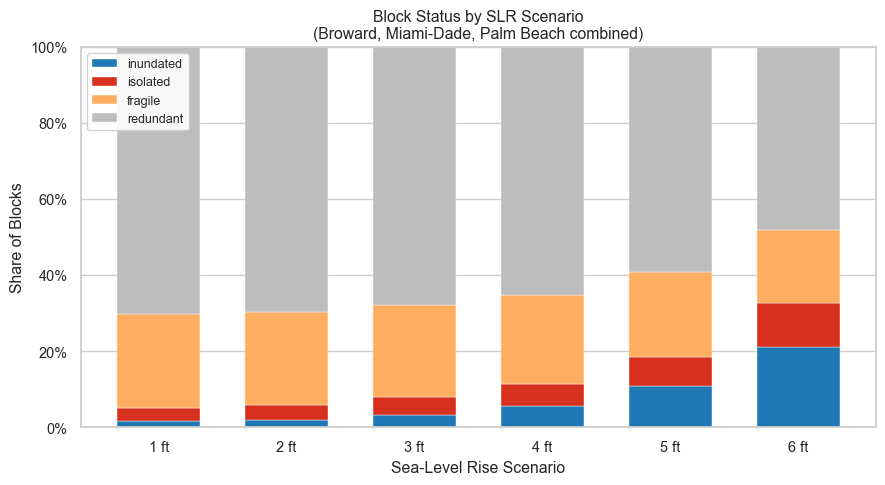

Saved: fig1_status_shares_by_slr.png


In [17]:
# Figure 1: Share of blocks by scenario status across SLR levels
status_by_slr = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["slr_ft", "scenario_status"])
    .size().reset_index(name="n")
)
total_slr = status_by_slr.groupby("slr_ft")["n"].transform("sum")
status_by_slr["share"] = status_by_slr["n"] / total_slr

pivot = (status_by_slr.pivot_table(index="slr_ft", columns="scenario_status",
                                    values="share", fill_value=0)
                       .reindex(SLR_LEVELS).fillna(0))

fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(SLR_LEVELS))
bottom = np.zeros(len(SLR_LEVELS))
for status in STATUS_ORDER:
    if status in pivot.columns:
        vals = pivot[status].values
        ax.bar(x, vals, bottom=bottom, label=status,
               color=STATUS_COLORS[status], width=0.65, edgecolor="white", linewidth=0.3)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"{ft} ft" for ft in SLR_LEVELS])
ax.set_xlabel("Sea-Level Rise Scenario")
ax.set_ylabel("Share of Blocks")
ax.set_title("Block Status by SLR Scenario\n(Broward, Miami-Dade, Palm Beach combined)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_status_shares_by_slr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_status_shares_by_slr.png")

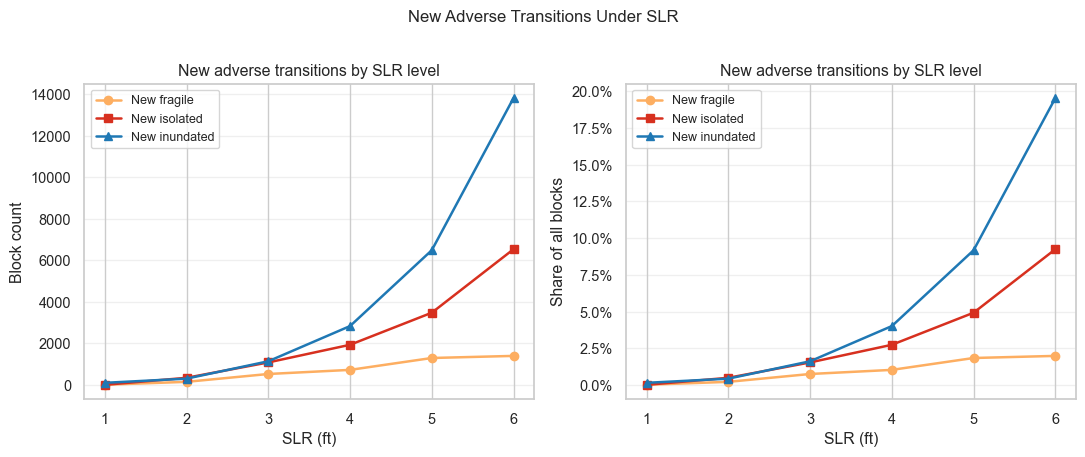

Saved: fig2_new_transitions_by_slr.png


In [18]:
# Figure 2: New adverse transitions by SLR level
n_all = int(transition_own["n_blocks"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, normalize, ylabel in [
    (axes[0], False, "Block count"),
    (axes[1], True,  "Share of all blocks"),
]:
    for col, label, marker, color in [
        ("n_new_fragile",   "New fragile",    "o", "#fdae61"),
        ("n_new_isolated",  "New isolated",   "s", "#d7301f"),
        ("n_new_inundated", "New inundated",  "^", "#1f78b4"),
    ]:
        vals = transition_own[col] / n_all if normalize else transition_own[col]
        ax.plot(transition_own["slr_ft"], vals, marker=marker,
                color=color, label=label, linewidth=1.8)
    ax.set_xlabel("SLR (ft)")
    ax.set_ylabel(ylabel)
    ax.set_title("New adverse transitions by SLR level")
    if normalize:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xticks(SLR_LEVELS)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("New Adverse Transitions Under SLR", fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_new_transitions_by_slr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_new_transitions_by_slr.png")

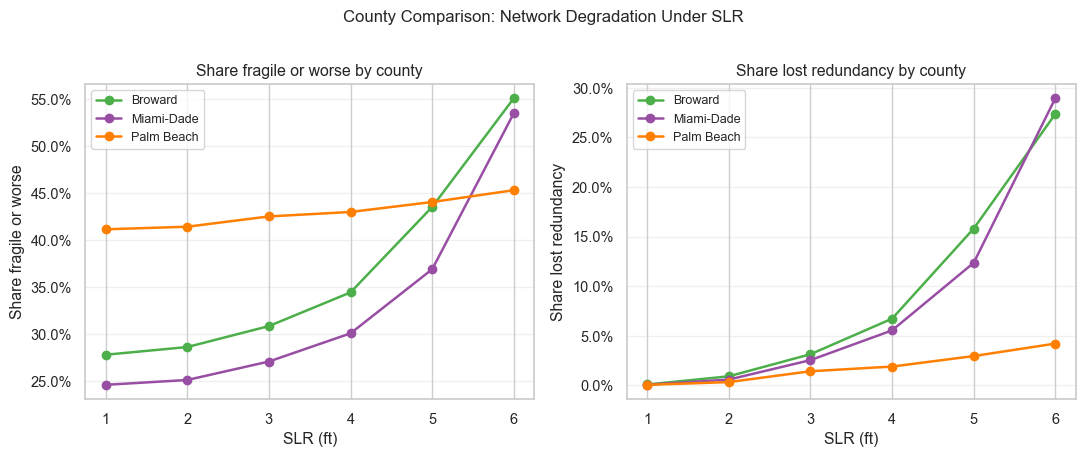

Saved: fig3_county_comparison.png


In [19]:
# Figure 3: County comparison
county_slr = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby(["county_name", "slr_ft"])
    .agg(
        total_blocks      = ("block_geoid",           "size"),
        n_fragile_worse   = ("fragile_or_worse",      "sum"),
        n_lost_redundancy = ("any_loss_of_redundancy","sum"),
    ).reset_index()
)
county_slr["share_fragile_or_worse"] = county_slr["n_fragile_worse"]   / county_slr["total_blocks"]
county_slr["share_lost_redundancy"]  = county_slr["n_lost_redundancy"] / county_slr["total_blocks"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title in [
    (axes[0], "share_fragile_or_worse", "Share fragile or worse"),
    (axes[1], "share_lost_redundancy",  "Share lost redundancy"),
]:
    for county, color in COUNTY_COLORS.items():
        sub = county_slr.loc[county_slr["county_name"] == county]
        ax.plot(sub["slr_ft"], sub[col], marker="o", color=color,
                label=county, linewidth=1.8)
    ax.set_xlabel("SLR (ft)")
    ax.set_ylabel(title)
    ax.set_title(title + " by county")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xticks(SLR_LEVELS)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("County Comparison: Network Degradation Under SLR", fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_county_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_county_comparison.png")

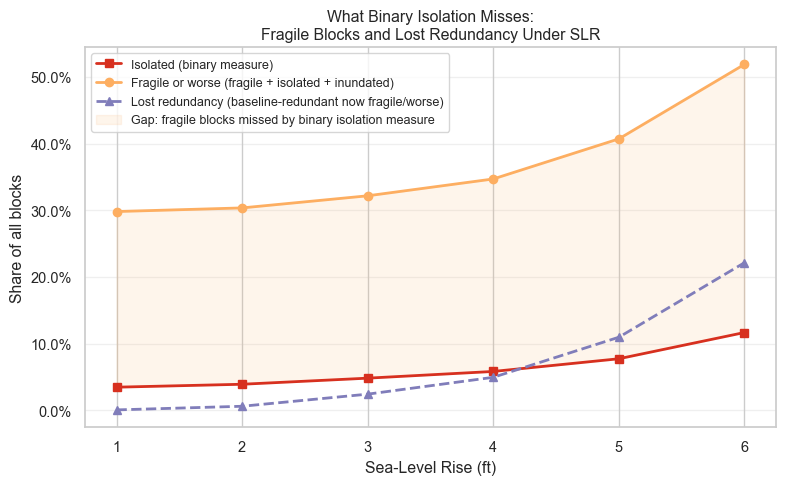

Saved: fig5_isolation_vs_redundancy.png


In [20]:
# Figure 5: Why redundancy measures add information beyond binary isolation
compare_df = (
    long_df.loc[long_df["slr_ft"] != 0]
    .groupby("slr_ft")
    .agg(
        n_blocks           = ("block_geoid",             "size"),
        n_isolated         = ("block_centroid_isolated",  "sum"),
        n_fragile_or_worse = ("fragile_or_worse",         "sum"),
        n_lost_redundancy  = ("any_loss_of_redundancy",   "sum"),
    ).reset_index()
)
compare_df["share_isolated"]         = compare_df["n_isolated"]         / compare_df["n_blocks"]
compare_df["share_fragile_or_worse"] = compare_df["n_fragile_or_worse"] / compare_df["n_blocks"]
compare_df["share_lost_redundancy"]  = compare_df["n_lost_redundancy"]  / compare_df["n_blocks"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(compare_df["slr_ft"], compare_df["share_isolated"],
        marker="s", color="#d7301f", linewidth=2, label="Isolated (binary measure)")
ax.plot(compare_df["slr_ft"], compare_df["share_fragile_or_worse"],
        marker="o", color="#fdae61", linewidth=2,
        label="Fragile or worse (fragile + isolated + inundated)")
ax.plot(compare_df["slr_ft"], compare_df["share_lost_redundancy"],
        marker="^", color="#807dba", linewidth=2, linestyle="--",
        label="Lost redundancy (baseline-redundant now fragile/worse)")
ax.fill_between(
    compare_df["slr_ft"],
    compare_df["share_isolated"],
    compare_df["share_fragile_or_worse"],
    alpha=0.12, color="#fdae61",
    label="Gap: fragile blocks missed by binary isolation measure"
)
ax.set_xlabel("Sea-Level Rise (ft)")
ax.set_ylabel("Share of all blocks")
ax.set_title("What Binary Isolation Misses:\nFragile Blocks and Lost Redundancy Under SLR")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_xticks(SLR_LEVELS)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig5_isolation_vs_redundancy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig5_isolation_vs_redundancy.png")

## 7A. Spatial Visualizations: SLR-Induced Transition Maps

These choropleths focus only on SLR-driven transitions out of the baseline redundant state.
For each block group x scenario, the mapped share uses:

`denominator = number of baseline-redundant blocks in the block group`

Block groups with zero baseline-redundant blocks are left as missing and plot in light gray.

| Figure | Variable mapped | Purpose |
|--------|-----------------|---------|
| **E1** | `share_red_to_fragile` at SLR 1-6 ft | First stage: loss of redundancy into fragility |
| **E2** | `share_red_to_isolated_or_inundated` at SLR 1-6 ft | More severe transition into disconnected or submerged states |
| **E3** | `share_red_to_inundated` at SLR 1-6 ft | Terminal transition to inundation |

Geometry: block polygons dissolved to block-group level from the repo's local GPKG.
Maps are projected to EPSG:32617 (UTM Zone 17N) for accurate rendering.


In [21]:
# ---------------------------------------------------------------------------
# Spatial visualization imports — requires the stat_geo (or equivalent) environment
# ---------------------------------------------------------------------------
try:
    import geopandas as gpd
    from matplotlib.colors import Normalize, TwoSlopeNorm
    from matplotlib.cm import ScalarMappable
    HAS_GEOPANDAS = True
    print(f"geopandas {gpd.__version__} ready.")
except ImportError:
    HAS_GEOPANDAS = False
    print("ERROR: geopandas not installed.")
    print("Run: conda install geopandas  (or activate the stat_geo environment)")
    print("Section 7A cells will no-op gracefully until geopandas is available.")

# Path to the local block polygon file
BLOCKS_GPKG = PROJECT_ROOT / "data" / "processed" / "census" / "blocks" / "fl_tricounty_blocks_2020.gpkg"

# CRS for map rendering — same UTM zone used throughout the analysis
MAP_CRS = "EPSG:32617"


# ---------------------------------------------------------------------------
# Geometry helper functions
# ---------------------------------------------------------------------------

def load_block_polygons(gpkg_path):
    """Load block polygons from the repo GPKG and standardize GEOID columns."""
    if not gpkg_path.exists():
        raise FileNotFoundError(
            f"Block geometry file not found:\n  {gpkg_path}\n"
            "Expected: data/processed/census/blocks/fl_tricounty_blocks_2020.gpkg"
        )
    gdf = gpd.read_file(gpkg_path)

    # The GPKG stores geometry as 'geom'; geopandas usually renames it to 'geometry',
    # but handle both cases defensively.
    if gdf.geometry.name != "geometry" and "geom" in gdf.columns:
        gdf = gdf.set_geometry("geom").rename_geometry("geometry")

    # Rename geoid -> block_geoid (consistent with analysis data)
    if "geoid" in gdf.columns and "block_geoid" not in gdf.columns:
        gdf = gdf.rename(columns={"geoid": "block_geoid"})

    # Standardize zero-padded GEOIDs
    for col, width in [("block_geoid", 15), ("block_group_geoid", 12),
                       ("tract_geoid", 11), ("county_fips", 3)]:
        if col in gdf.columns:
            gdf[col] = gdf[col].astype(str).str.zfill(width)
    return gdf


def dissolve_to_block_groups(blocks_gdf, target_crs=MAP_CRS):
    """Dissolve block polygons to block-group polygons.
    county_fips and county_name are constant within a block group, so 'first' is correct.
    """
    gdf = blocks_gdf.to_crs(target_crs)
    slim = gdf[["block_group_geoid", "county_fips", "county_name", "geometry"]].copy()
    bg = slim.dissolve(by="block_group_geoid", aggfunc="first").reset_index()
    bg["block_group_geoid"] = bg["block_group_geoid"].astype(str).str.zfill(12)
    bg["county_fips"]       = bg["county_fips"].astype(str).str.zfill(3)
    return bg


def make_county_outlines(bg_gdf):
    """Dissolve block-group polygons to county outlines for overlay reference."""
    return (bg_gdf.dissolve(by="county_name", aggfunc="first")
                  .reset_index()[["county_name", "geometry"]])

geopandas 1.1.2 ready.


In [22]:
# ---------------------------------------------------------------------------
# Load block polygons and dissolve to block-group and county geometries
# ---------------------------------------------------------------------------
if not HAS_GEOPANDAS:
    print("geopandas not available — skipping geometry load.")
    bg_geom = None
    county_outlines = None
else:
    print("Loading block polygons (may take ~20–30 s for 70k polygons)...")
    blocks_gdf = load_block_polygons(BLOCKS_GPKG)
    print(f"  {len(blocks_gdf):,} block polygons | CRS: {blocks_gdf.crs.to_epsg()}")

    print("Dissolving to block-group polygons...")
    bg_geom = dissolve_to_block_groups(blocks_gdf)
    del blocks_gdf   # free ~200 MB of block-level geometry
    print(f"  {len(bg_geom):,} block-group polygons | CRS: {bg_geom.crs.to_epsg()}")

    county_outlines = make_county_outlines(bg_geom)
    print(f"  County outlines: {county_outlines['county_name'].tolist()}")

    # Quick sanity: every block group in bg_geom should be in bg_analysis
    bg_geom_ids  = set(bg_geom["block_group_geoid"])
    bg_analy_ids = set(bg_analysis["block_group_geoid"])
    missing_in_analysis = bg_geom_ids - bg_analy_ids
    if missing_in_analysis:
        print(f"  NOTE: {len(missing_in_analysis)} BG polygons have no analysis row "
              f"(will appear gray on maps).")
    else:
        print("  Geometry-to-analysis match: all BG polygons have analysis data.")

Loading block polygons (may take ~20–30 s for 70k polygons)...
  70,695 block polygons | CRS: 4269
Dissolving to block-group polygons...
  3,946 block-group polygons | CRS: 32617
  County outlines: ['Broward', 'Miami-Dade', 'Palm Beach']
  Geometry-to-analysis match: all BG polygons have analysis data.


In [23]:
# ---------------------------------------------------------------------------
# Build the map GeoDataFrame: geometry + block-group analysis data
# ---------------------------------------------------------------------------
if not HAS_GEOPANDAS or bg_geom is None:
    print("Skipping map data prep - geometry not loaded.")
    map_gdf = None
else:
    map_gdf = bg_geom.merge(
        bg_analysis,
        on="block_group_geoid",
        how="left",
        validate="one_to_many",
    )

    for dup in ["county_fips_x", "county_name_x", "county_fips_y", "county_name_y"]:
        if dup in map_gdf.columns:
            clean = dup.rstrip("_xy")
            if clean not in map_gdf.columns:
                map_gdf = map_gdf.rename(columns={dup: clean})
            else:
                map_gdf = map_gdf.drop(columns=[dup])

    map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=MAP_CRS)

    n_bgs = map_gdf["block_group_geoid"].nunique()
    n_rows = len(map_gdf)
    print(f"map_gdf: {n_rows:,} rows ({n_bgs:,} block groups x {map_gdf['slr_ft'].nunique()} SLR levels)")

    preview_cols = [
        c
        for c in [
            "baseline_redundant_blocks",
            "share_red_to_fragile",
            "share_red_to_isolated",
            "share_red_to_isolated_or_inundated",
            "share_red_to_inundated",
            "share_red_to_fragile_or_worse",
            "pct_nonwhite",
            "poverty_rate",
            "renter_share",
        ]
        if c in map_gdf.columns
    ]
    slr3 = map_gdf.loc[map_gdf["slr_ft"] == 3, preview_cols]
    display(slr3.describe().loc[["mean", "50%", "max"]].rename(index={"50%": "median"}).round(4))


map_gdf: 27,622 rows (3,946 block groups x 7 SLR levels)


,baseline_redundant_blocks,share_red_to_fragile,share_red_to_isolated,share_red_to_isolated_or_inundated,share_red_to_inundated,share_red_to_fragile_or_worse,pct_nonwhite,poverty_rate,renter_share
mean,12.5879,0.0160,0.0204,0.0400,0.0196,0.0560,0.6850,NaN,0.3819
median,11.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7736,NaN,0.3259
max,130.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,1.0000


In [24]:
# ---------------------------------------------------------------------------
# Map plotting helper functions (reused across all figures in 7A)
# ---------------------------------------------------------------------------

def _clean_ax(ax):
    """Remove ticks and frame for a clean map panel."""
    ax.set_axis_off()


def choropleth(ax, gdf, col, cmap, norm, county_gdf, title="", subtitle=""):
    """
    Draw a choropleth on ax.

    Approach: paint all block groups gray first (background / missing data),
    then overlay rows with valid data using the specified cmap/norm.
    County outlines are added last.

    Parameters
    ----------
    ax            : matplotlib Axes
    gdf           : GeoDataFrame with geometry and `col`
    col           : column name to map
    cmap          : matplotlib colormap name or object
    norm          : matplotlib Normalize or TwoSlopeNorm
    county_gdf    : GeoDataFrame of county outlines
    title         : panel title (bold)
    subtitle      : smaller text below the panel
    """
    # 1. Gray background for all polygons (catches missing-value areas too)
    gdf.plot(ax=ax, color="#e8e8e8", linewidth=0)

    # 2. Choropleth: only rows with valid (non-NaN) data
    valid = gdf.loc[gdf[col].notna()].copy()
    if not valid.empty:
        valid.plot(ax=ax, column=col, cmap=cmap, norm=norm,
                   linewidth=0, legend=False)

    # 3. County outlines for geographic reference
    county_gdf.boundary.plot(ax=ax, color="#333333", linewidth=0.9, zorder=5)

    if title:
        ax.set_title(title, fontsize=9.5, fontweight="bold", pad=3)
    if subtitle:
        ax.text(0.5, -0.02, subtitle, transform=ax.transAxes,
                ha="center", fontsize=7.5, color="#555555", style="italic")
    _clean_ax(ax)


def add_colorbar(fig, ax_or_axes, cmap, norm, label="", pct=False):
    """
    Attach a colorbar to fig.

    ax_or_axes : single Axes or list of Axes (for shared colorbar in small multiples)
    pct        : if True, format tick labels as percentages (assumes values 0–1)
    """
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_or_axes, fraction=0.022, pad=0.02, shrink=0.65)
    if pct:
        cbar.ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:.0%}")
        )
    cbar.set_label(label, fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    return cbar


print("Map helper functions defined: choropleth(), add_colorbar()")

Map helper functions defined: choropleth(), add_colorbar()


In [25]:
# ---------------------------------------------------------------------------
# Transition-map helper for compact small multiples across SLR scenarios
# ---------------------------------------------------------------------------
def plot_transition_small_multiples(metric, figure_title, colorbar_label, output_name, cmap="YlOrRd"):
    if map_gdf is None:
        print(f"Skipping {output_name}.")
        return
    if metric not in map_gdf.columns:
        print(f"Column not found: {metric}")
        return

    positive = map_gdf.loc[map_gdf["slr_ft"].isin(SLR_LEVELS), metric].dropna()
    if positive.empty:
        print(f"No positive-SLR values available for {metric}.")
        return

    vmax = float(positive.quantile(0.95))
    vmax = max(vmax, 0.01)
    norm = Normalize(vmin=0, vmax=vmax)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(12.4, 7.8),
        gridspec_kw={"wspace": 0.01, "hspace": 0.04},
    )
    axes = axes.flatten()

    for ax, slr_ft in zip(axes, SLR_LEVELS):
        data = map_gdf.loc[map_gdf["slr_ft"] == slr_ft].copy()
        choropleth(
            ax,
            data,
            metric,
            cmap,
            norm,
            county_outlines,
            title=f"SLR {slr_ft} ft",
        )

    fig.suptitle(figure_title, fontsize=11, y=0.975)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.11, wspace=0.01, hspace=0.04)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cax = fig.add_axes([0.29, 0.055, 0.42, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(colorbar_label, fontsize=9, labelpad=2)
    cbar.ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    cbar.ax.tick_params(labelsize=8)

    fig.text(
        0.5,
        0.018,
        "Gray indicates block groups with no baseline-redundant blocks or no mapped value.",
        ha="center",
        fontsize=7.5,
        color="#666666",
    )

    fig.savefig(FIGURES_DIR / output_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_name}")
    print(f"  Shared color scale: 0 to {vmax:.1%} (95th percentile across SLR 1-6)")


print("Transition small-multiple helper defined: plot_transition_small_multiples()")


Transition small-multiple helper defined: plot_transition_small_multiples()


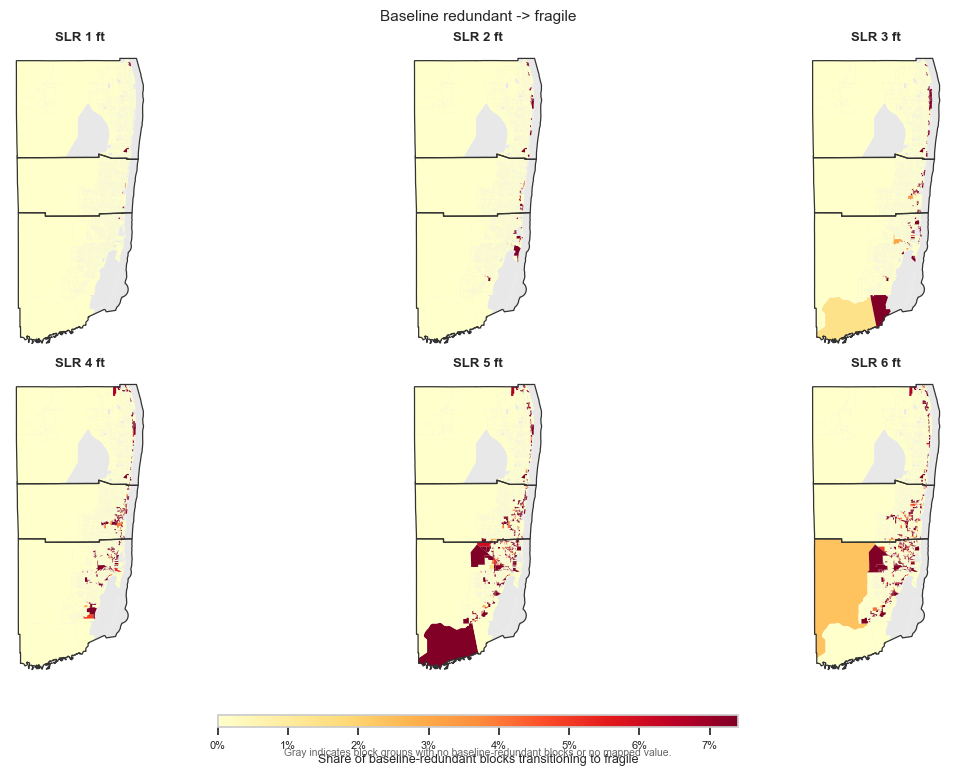

Saved: figE1_redundant_to_fragile_small_multiples.png
  Shared color scale: 0 to 7.4% (95th percentile across SLR 1-6)


In [26]:
# ---------------------------------------------------------------------------
# Figure E1: baseline-redundant blocks that transition to fragile
# Maps the share of baseline-redundant blocks in each block group that become fragile
# under each positive SLR scenario.
# ---------------------------------------------------------------------------
plot_transition_small_multiples(
    metric="share_red_to_fragile",
    figure_title="Baseline redundant -> fragile",
    colorbar_label="Share of baseline-redundant blocks transitioning to fragile",
    output_name="figE1_redundant_to_fragile_small_multiples.png",
    cmap="YlOrRd",
)


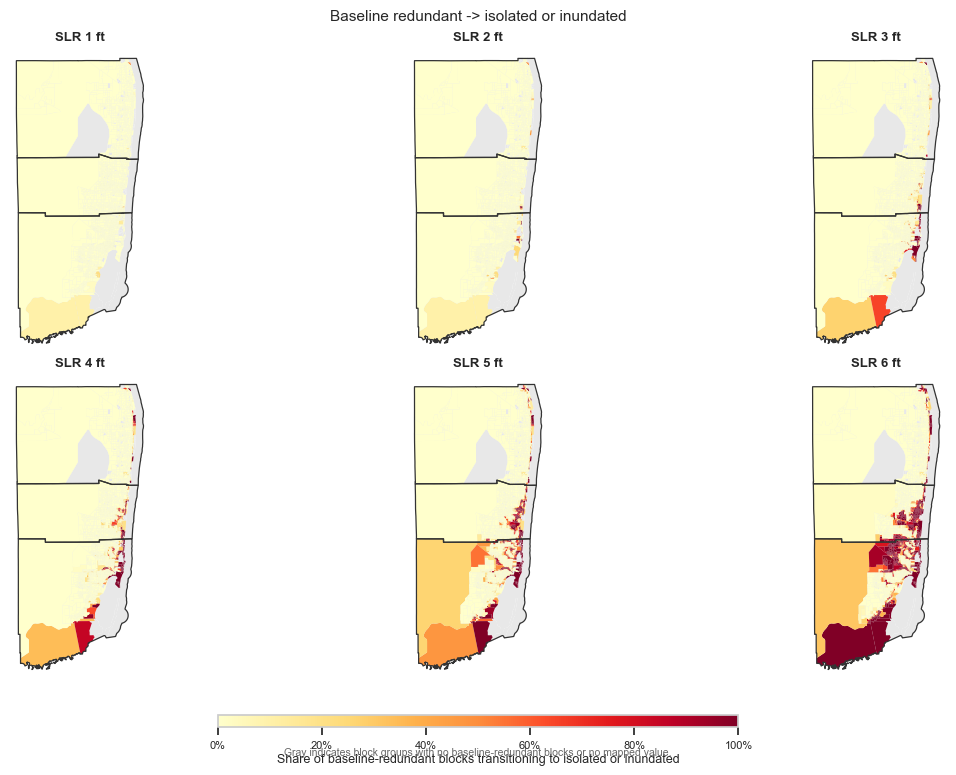

Saved: figE2_redundant_to_isolated_or_inundated_small_multiples.png
  Shared color scale: 0 to 100.0% (95th percentile across SLR 1-6)


In [27]:
# ---------------------------------------------------------------------------
# Figure E2: baseline-redundant blocks that transition to isolated or inundated
# Maps the share of baseline-redundant blocks in each block group that move into
# more severe disconnected or submerged states under each positive SLR scenario.
# ---------------------------------------------------------------------------
plot_transition_small_multiples(
    metric="share_red_to_isolated_or_inundated",
    figure_title="Baseline redundant -> isolated or inundated",
    colorbar_label="Share of baseline-redundant blocks transitioning to isolated or inundated",
    output_name="figE2_redundant_to_isolated_or_inundated_small_multiples.png",
    cmap="YlOrRd",
)


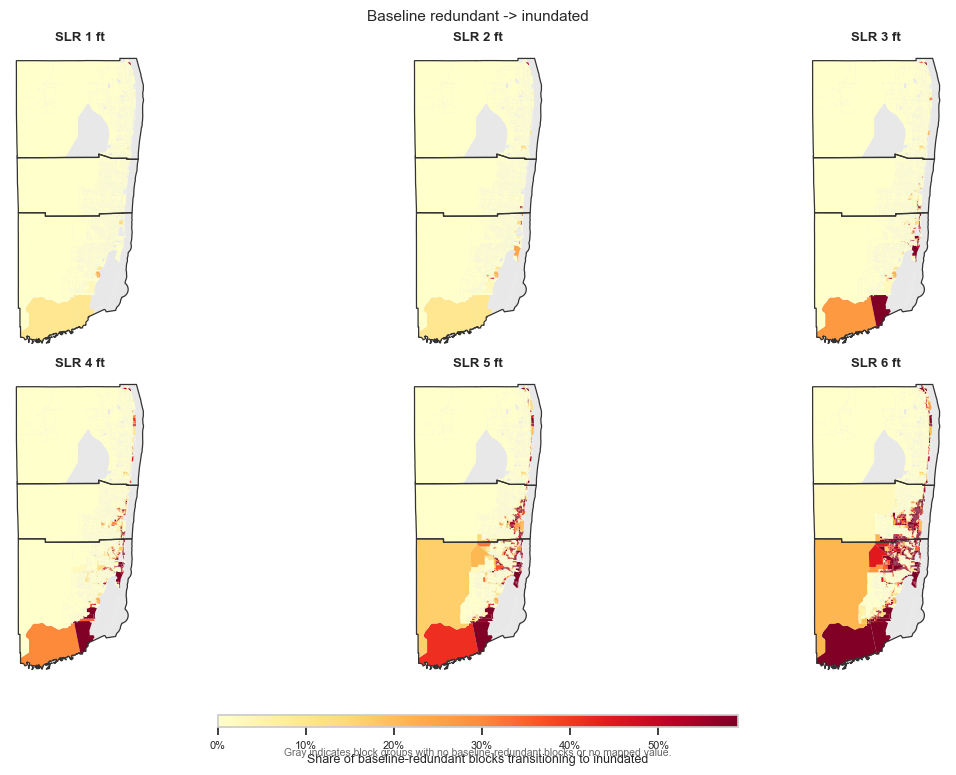

Saved: figE3_redundant_to_inundated_small_multiples.png
  Shared color scale: 0 to 59.1% (95th percentile across SLR 1-6)

Section 7A transition figure files:
  figE1_redundant_to_fragile_small_multiples.png (saved)
  figE2_redundant_to_isolated_or_inundated_small_multiples.png (saved)
  figE3_redundant_to_inundated_small_multiples.png (saved)


In [28]:
# ---------------------------------------------------------------------------
# Figure E3: baseline-redundant blocks that transition to inundated
# Maps the share of baseline-redundant blocks in each block group that become
# inundated under each positive SLR scenario.
# ---------------------------------------------------------------------------
plot_transition_small_multiples(
    metric="share_red_to_inundated",
    figure_title="Baseline redundant -> inundated",
    colorbar_label="Share of baseline-redundant blocks transitioning to inundated",
    output_name="figE3_redundant_to_inundated_small_multiples.png",
    cmap="YlOrRd",
)

saved_maps = [
    "figE1_redundant_to_fragile_small_multiples.png",
    "figE2_redundant_to_isolated_or_inundated_small_multiples.png",
    "figE3_redundant_to_inundated_small_multiples.png",
]
print("\nSection 7A transition figure files:")
for f in saved_maps:
    p = FIGURES_DIR / f
    status = "saved" if p.exists() else "not yet saved"
    print(f"  {f} ({status})")


### Section 7A - Transition Map Notes

These spatial figures map SLR-induced degradation only. For each block group and SLR
scenario, the denominator is the number of blocks that were redundant at baseline.
Block groups with zero baseline-redundant blocks are shown in gray rather than treated as zero.

**Figure E1** (`figE1_redundant_to_fragile_small_multiples.png`)
Shares of baseline-redundant blocks that transition to fragile under each SLR scenario.
This is the first stage of degradation: redundancy is lost, but some dry access remains.

**Figure E2** (`figE2_redundant_to_isolated_or_inundated_small_multiples.png`)
Shares of baseline-redundant blocks that transition to isolated or inundated under each SLR
scenario. This captures a more severe loss of access than the fragile transition alone.

**Figure E3** (`figE3_redundant_to_inundated_small_multiples.png`)
Shares of baseline-redundant blocks that transition all the way to inundated under each SLR
scenario. This is the terminal transition in the nested worsening story.


In [29]:
# ---------------------------------------------------------------------------
# Export map_gdf to GeoPackage for QGIS
#
# One layer per SLR scenario (slr_0ft ... slr_6ft) plus a stacked all_scenarios
# layer for filtering in QGIS.
#
# Transition shares are defined relative to baseline-redundant blocks and remain
# NaN where a block group has no baseline-redundant denominator.
# ---------------------------------------------------------------------------
if map_gdf is None:
    print("map_gdf not built - run the Section 7A geometry cells first.")
else:
    SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
    SPATIAL_DIR.mkdir(parents=True, exist_ok=True)
    GPKG_OUT = SPATIAL_DIR / "slr_block_group_analysis.gpkg"

    EXPORT_COLS = [
        "block_group_geoid",
        "county_fips",
        "county_name",
        "tract_geoid",
        "slr_ft",
        "total_blocks",
        "baseline_redundant_blocks",
        "share_inundated",
        "share_isolated",
        "share_fragile",
        "share_redundant",
        "share_fragile_or_worse",
        "share_lost_redundancy",
        "share_new_fragile",
        "share_new_isolated",
        "share_new_inundated",
        "share_red_to_fragile",
        "share_red_to_isolated",
        "share_red_to_inundated",
        "share_red_to_isolated_or_inundated",
        "share_red_to_fragile_or_worse",
        "mean_path_inflation_ratio",
        "median_path_inflation_ratio",
        "mean_max_edge_disjoint_paths",
        "median_max_edge_disjoint_paths",
        "any_loss_of_redundancy",
        "new_fragile_due_to_slr",
        "new_isolated_due_to_slr",
        "new_inundated_due_to_slr",
        "baseline_redundant_to_fragile",
        "baseline_redundant_to_isolated",
        "baseline_redundant_to_inundated",
        "baseline_redundant_to_isolated_or_inundated",
        "baseline_redundant_to_fragile_or_worse",
    ]
    EXPORT_COLS += [
        c
        for c in [
            "total_pop",
            "median_income",
            "pct_nonwhite",
            "pct_black_nh",
            "pct_hispanic",
            "renter_share",
            "poverty_rate",
            "log_median_income",
        ]
        if c in map_gdf.columns
    ]

    EXPORT_COLS = [c for c in EXPORT_COLS if c in map_gdf.columns]
    export_gdf = map_gdf[EXPORT_COLS + ["geometry"]].copy()

    if GPKG_OUT.exists():
        GPKG_OUT.unlink()

    slr_levels_present = sorted(export_gdf["slr_ft"].unique())
    for slr_ft_val in slr_levels_present:
        layer_name = f"slr_{slr_ft_val}ft"
        layer_data = export_gdf.loc[export_gdf["slr_ft"] == slr_ft_val].drop(columns=["slr_ft"])
        layer_data.to_file(GPKG_OUT, layer=layer_name, driver="GPKG")
        print(f"  Layer '{layer_name}': {len(layer_data):,} block groups")

    export_gdf.to_file(GPKG_OUT, layer="all_scenarios", driver="GPKG")

    file_mb = GPKG_OUT.stat().st_size / (1024 ** 2)
    print(f"Saved: {GPKG_OUT}")
    print(f"  Size: {file_mb:,.1f} MB")
    print("Each SLR layer is a standalone snapshot; 'all_scenarios' lets you filter by slr_ft.")


  Layer 'slr_0ft': 3,946 block groups
  Layer 'slr_1ft': 3,946 block groups
  Layer 'slr_2ft': 3,946 block groups
  Layer 'slr_3ft': 3,946 block groups
  Layer 'slr_4ft': 3,946 block groups
  Layer 'slr_5ft': 3,946 block groups
  Layer 'slr_6ft': 3,946 block groups
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\spatial\slr_block_group_analysis.gpkg
  Size: 96.8 MB
Each SLR layer is a standalone snapshot; 'all_scenarios' lets you filter by slr_ft.


## 8. Save All Outputs

Write analysis-ready files to disk.

In [30]:
# ---------------------------------------------------------------------------
# Save all outputs to disk (CSV only!)
# ---------------------------------------------------------------------------

# 1. Block-level long dataset
block_csv_out = ANALYSIS_DIR / "block_level_long_dataset.csv"
long_df.to_csv(block_csv_out, index=False)
print(f"Saved: {block_csv_out}")

# Also a CSV sample for quick inspection
sample_out = ANALYSIS_DIR / "block_level_long_dataset_sample5k.csv"
long_df.sample(n=min(5000, len(long_df)), random_state=42).to_csv(sample_out, index=False)
print(f"Saved sample: {sample_out}")

# 2. Block-group analysis dataset
bg_csv_out = ANALYSIS_DIR / "block_group_analysis_dataset.csv"
bg_analysis.to_csv(bg_csv_out, index=False)
print(f"Saved: {bg_csv_out}")

# 3. Tract-level dataset
if "tract_df" in locals() and tract_df is not None:
    tract_csv_out = ANALYSIS_DIR / "tract_analysis_dataset.csv"
    tract_df.to_csv(tract_csv_out, index=False)
    print(f"Saved: {tract_csv_out}")
else:
    print("No tract-level dataset to save.")

# 4. Transition summary tables
transition_out = TABLES_DIR / "transition_summary_by_slr.csv"
crosstab_out = TABLES_DIR / "baseline_vs_scenario_crosstab_validated.csv"

transition_own.to_csv(transition_out, index=False)
crosstab_own.to_csv(crosstab_out, index=False)

print(f"Saved: {transition_out}")
print(f"Saved: {crosstab_out}")

# 5. Regression results (if available)
if "results_df" in locals() and results_df is not None:
    regression_out = TABLES_DIR / "regression_summary.csv"
    results_df.to_csv(regression_out, index=False)
    print(f"Saved: {regression_out}")
else:
    print("No regression results to save (Section 8 not run or demographics unavailable).")

print("\nAll outputs saved.")
print(f"  Analysis data : {ANALYSIS_DIR}")
print(f"  Figures       : {FIGURES_DIR}")
print(f"  Tables        : {TABLES_DIR}")

Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_level_long_dataset.csv
Saved sample: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_level_long_dataset_sample5k.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\block_group_analysis_dataset.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis\tract_analysis_dataset.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\tables\transition_summary_by_slr.csv
Saved: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\tables\baseline_vs_scenario_crosstab_validated.csv
No regression results to save (Section 8 not run or demographics unavailable).

All outputs saved.
  Analysis data : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\analysis
  Figures       : C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\outputs\figures
  Tables        : C:\Users\Vivek\Dropbox\

## 9. Sandbox

In [31]:
bg_analysis['baseline_isolated_to_inundated']

0        0
1        0
2        0
3        0
4        0
        ..
27617    0
27618    0
27619    0
27620    0
27621    0
Name: baseline_isolated_to_inundated, Length: 27622, dtype: int64